# Does a high copper-to-aluminium price ratio say anything about the next 6 and 12 months?

**Business question (whole project):** who needs copper, who supplies it, and what does the price do when they collide? This notebook covers the second hypothesis, reframed as a **price question only**.

**H2.** When copper is expensive compared with aluminium (a high copper-to-aluminium price ratio), the ratio tends to fall back over the next 6 and 12 months, so copper becomes cheaper relative to aluminium. This is a prediction of "mean reversion" in the relative price, stated before looking at any result.

**What this notebook does not do.** People in the industry discuss swapping aluminium for copper when copper gets too dear. This project has **no demand data**, so substitution itself is neither tested nor claimed here. The ratio is shown as context, and a small arithmetic scenario shows what it would take for the ratio to return to earlier levels.

**Data.** World Bank monthly copper and aluminium prices, nominal US dollars per tonne, January 1960 to August 2026 (source S02). Each is a monthly average.

**Read this first.** These are historical associations in one sample. They are not forecasts and not investment advice. Run `python copper_database/build_db.py --raw .` first so that `copper.db` exists.

In [1]:
import sqlite3
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint

warnings.filterwarnings("ignore")

# Three colours from the validated reference palette, used in a fixed order (blue, orange, aqua)
BLUE, ORANGE, AQUA, INK, GRID = "#2a78d6", "#eb6834", "#1baf7a", "#0b0b0b", "#dcdcd8"
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#8a8984", "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.labelsize": 10,
    "text.color": INK, "axes.labelcolor": "#52514e", "xtick.color": "#52514e", "ytick.color": "#52514e",
    "lines.linewidth": 1.8, "legend.frameon": False,
})


def show(df, nd=2):
    """Round for display; p-values below 0.001 are shown as <0.001."""
    out = df.copy()
    for c in out.columns:
        if c.startswith("p_"):
            out[c] = out[c].map(lambda v: "<0.001" if v < 0.001 else f"{v:.3f}")
    return out.round(nd)


con = sqlite3.connect("../copper_database/copper.db")
ratio = pd.read_sql("SELECT * FROM mart_cu_al_ratio", con, parse_dates=["month"]).set_index("month")
rules = pd.read_sql("SELECT * FROM mart_cu_al_rules", con)
sig = pd.read_sql("SELECT * FROM mart_cu_al_signal_months", con, parse_dates=["month"])
print(f"Ratio table: {len(ratio)} months, {ratio.index.min():%Y-%m} to {ratio.index.max():%Y-%m}; {len(rules)} rules")

Ratio table: 800 months, 1960-01 to 2026-08; 17 rules


## 1. Context: how expensive is copper compared with aluminium, and how unusual is today?

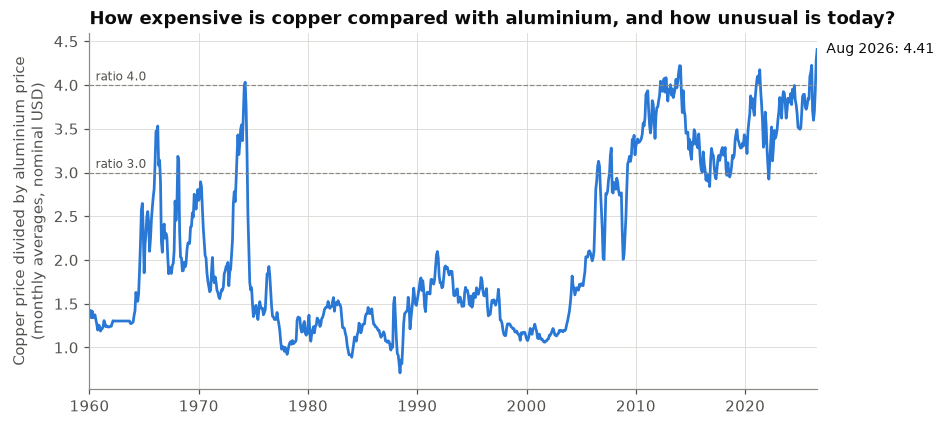

In [2]:
fig, ax = plt.subplots()
ax.plot(ratio.index, ratio["cu_al_ratio"], color=BLUE)
for lvl in (3.0, 4.0):
    ax.axhline(lvl, color="#8a8984", lw=0.8, ls="--")
    ax.annotate(f"ratio {lvl:.1f}", (ratio.index[0], lvl), xytext=(4, 3), textcoords="offset points", fontsize=8, color="#52514e")
last = ratio.iloc[-1]
ax.annotate(f"{ratio.index[-1]:%b %Y}: {last['cu_al_ratio']:.2f}", (ratio.index[-1], last["cu_al_ratio"]), xytext=(6, 0),
            textcoords="offset points", fontsize=9, va="center")
ax.set_xlim(ratio.index[0], ratio.index[-1])
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.figure.subplots_adjust(right=0.86)
ax.set_title("How expensive is copper compared with aluminium, and how unusual is today?")
ax.set_ylabel("Copper price divided by aluminium price\n(monthly averages, nominal USD)")
plt.show()

In [3]:
dec = ratio["cu_al_ratio"].groupby((ratio.index.year // 10 * 10).astype(str) + "s").agg(["min", "median", "max"])
dec.columns = ["lowest", "median", "highest"]
dec

,lowest,median,highest
month,,,
1960s,1.187867,1.879317,3.531481
1970s,0.921272,1.633030,4.031915
1980s,0.709894,1.260431,1.678696
1990s,1.081369,1.590007,2.096916
2000s,1.060223,1.724852,3.425346
2010s,2.839736,3.380322,4.221772
2020s,2.924814,3.732518,4.406644


The ratio did not wander around one level. For decades its median was between about 1.3 and 1.9; since 2010 it has stayed between about 2.8 and 4.4. Today's value is the highest in the whole history. This matters for every test below: a *fixed* threshold such as 3.0 mostly describes the post-2010 period, and there are very few independent episodes to learn from.

## 2. Scenario (arithmetic, not a forecast)

What would it take for the ratio to come back to a reference level? Two stylised cases: copper falls and aluminium stays at today's price, or aluminium rises and copper stays at today's price. In reality both move.

In [4]:
today = ratio.iloc[-1]
refs = {
    "median since 1970": ratio.loc["1970-01-01":, "cu_al_ratio"].median(),
    "median since 2010": ratio.loc["2010-01-01":, "cu_al_ratio"].median(),
    "median of the last 10 years": ratio.iloc[-120:]["cu_al_ratio"].median(),
}
ctx = pd.DataFrame({
    "reference ratio": refs,
}).assign(**{
    "today's ratio": today["cu_al_ratio"],
    "copper would have to fall by (%), aluminium unchanged": [(r / today["cu_al_ratio"] - 1) * 100 for r in refs.values()],
    "aluminium would have to rise by (%), copper unchanged": [(today["cu_al_ratio"] / r - 1) * 100 for r in refs.values()],
})
ctx.index.name = "back to the"
print(f"{ratio.index[-1]:%B %Y}: copper {today['copper_usd_t_avg']:,.0f} and aluminium {today['aluminium_usd_t_avg']:,.0f} USD per tonne, "
      f"ratio {today['cu_al_ratio']:.2f}; percentile of its own past: {today['cu_al_ratio_pctile_all_past']:.1f} (all earlier months), "
      f"{today['cu_al_ratio_pctile_past_10y']:.1f} (previous 10 years)")
ctx.round(2)

August 2026: copper 14,326 and aluminium 3,251 USD per tonne, ratio 4.41; percentile of its own past: 100.0 (all earlier months), 100.0 (previous 10 years)


,reference ratio,today's ratio,"copper would have to fall by (%), aluminium unchanged","aluminium would have to rise by (%), copper unchanged"
back to the,,,,
median since 1970,1.71,4.41,-61.30,158.38
median since 2010,3.54,4.41,-19.56,24.32
median of the last 10 years,3.51,4.41,-20.28,25.44


## 3. How the test is set up

- **Outcome.** The log change of the ratio over the next 6 (or 12) months. This equals copper's log return minus aluminium's, so a negative number means copper got cheaper relative to aluminium. H2 predicts a more negative outcome after a high ratio.
- **Signals.** Three families of "ratio is high" rules, shown as a table by threshold so you can choose your own:
  a **fixed ratio** (for example at or above 3.0); the ratio's **percentile among all earlier months** (since 1960); and the ratio's **percentile among the previous 10 years**, which adapts to the changed price level.
  Percentiles use only past data at each date, so there is no look-ahead.
- **Sample.** From January 1970 (when 10 years of history exist) to the last month with a known outcome, the same months for every rule: 674 months for the 6-month outcome and 668 for the 12-month outcome.
- **Overlapping windows.** Neighbouring months share most of their forward window, so a naive test would count the same episode many times. Two answers, shown side by side:
  (a) all months, with Newey-West (HAC) standard errors that allow for the overlap (lags = the horizon);
  (b) **independent episodes**: signal months whose forward windows overlap are merged into one episode, and only the first month of each episode is used. The number of episodes is the honest sample size.
- **Many rules, one question.** There are 17 rules and 2 horizons, so some will look significant by chance. A Holm-adjusted p-value is shown next to the raw one. Read the pattern across thresholds, not the single best row.

In [5]:
def summarize(g, h):
    on, off = g[g["signal_on"] == 1], g[g["signal_on"] == 0]
    row = {"horizon_m": h, "months_on": len(on), "months_off": len(off), "share_on_pct": len(on) / len(g) * 100,
           "episodes": int(on["episode_id"].nunique())}
    f = lambda x: (np.exp(x) - 1) * 100  # mean log change -> geometric average % change
    row["avg_ratio_change_all_pct"] = f(g["fwd_ratio_logchg"].mean())
    row["avg_ratio_change_on_pct"] = f(on["fwd_ratio_logchg"].mean()) if len(on) else np.nan
    row["avg_ratio_change_off_pct"] = f(off["fwd_ratio_logchg"].mean()) if len(off) else np.nan
    row["falling_share_on_pct"] = (on["fwd_ratio_logchg"] < 0).mean() * 100 if len(on) else np.nan
    row["falling_share_off_pct"] = (off["fwd_ratio_logchg"] < 0).mean() * 100 if len(off) else np.nan
    row["avg_copper_change_on_pct"] = f(on["fwd_copper_logret"].mean()) if len(on) else np.nan
    row["avg_aluminium_change_on_pct"] = f(on["fwd_aluminium_logret"].mean()) if len(on) else np.nan
    if len(on) >= 2 and len(off) >= 2:
        m = sm.OLS(g["fwd_ratio_logchg"].to_numpy(), sm.add_constant(g["signal_on"].astype(float).to_numpy())).fit(
            cov_type="HAC", cov_kwds={"maxlags": h})
        ci = m.conf_int()[1]
        row.update({"diff_logpts": m.params[1] * 100, "diff_ci_low": ci[0] * 100, "diff_ci_high": ci[1] * 100, "p_hac": m.pvalues[1]})
    else:
        row.update({"diff_logpts": np.nan, "diff_ci_low": np.nan, "diff_ci_high": np.nan, "p_hac": np.nan})
    st = on[on["is_episode_start"] == 1]
    row["episode_avg_change_pct"] = f(st["fwd_ratio_logchg"].mean()) if len(st) else np.nan
    row["episodes_falling"] = int((st["fwd_ratio_logchg"] < 0).sum())
    if len(st):
        lo, hi = proportion_confint(row["episodes_falling"], len(st), alpha=0.05, method="wilson")
        row["episodes_falling_ci_low_pct"], row["episodes_falling_ci_high_pct"] = lo * 100, hi * 100
    else:
        row["episodes_falling_ci_low_pct"] = row["episodes_falling_ci_high_pct"] = np.nan
    return row


rows = []
for (rid, h), g in sig.groupby(["rule_id", "horizon_m"]):
    rows.append({"rule_id": rid, **summarize(g, h)})
thr = pd.DataFrame(rows).merge(rules, on="rule_id")
ok = thr["p_hac"].notna()
thr.loc[ok, "p_holm"] = multipletests(thr.loc[ok, "p_hac"], method="holm")[1]
short = {"fixed_ratio": "ratio at or above {t:.1f}", "pctile_all_past": "percentile (all earlier months) at or above {t:.0f}",
         "pctile_past_10y": "percentile (previous 10 years) at or above {t:.0f}"}
thr["rule"] = [short[r].format(t=t) for r, t in zip(thr["rule_type"], thr["threshold"])]
thr = thr.sort_values(["horizon_m", "rule_id"]).reset_index(drop=True)
cols = ["rule", "months_on", "episodes", "avg_ratio_change_on_pct", "avg_ratio_change_off_pct", "diff_logpts", "diff_ci_low", "diff_ci_high",
        "p_hac", "p_holm", "episodes_falling"]
print("All months in the sample: average change of the ratio over the next 6 months {:.1f}%, over the next 12 months {:.1f}%".format(
    thr.loc[thr.horizon_m == 6, "avg_ratio_change_all_pct"].iloc[0], thr.loc[thr.horizon_m == 12, "avg_ratio_change_all_pct"].iloc[0]))

All months in the sample: average change of the ratio over the next 6 months 0.3%, over the next 12 months 1.0%


### Results by threshold: next 12 months
*Average change* columns are the geometric average % change of the ratio over the next 12 months when the signal was on and when it was off. *Difference* is on minus off in log points x 100 (about percentage points), with a 95% HAC interval. A negative difference matches H2. *Episodes falling* is how many of the independent episodes saw the ratio lower 12 months after they started.

In [6]:
show(thr[thr["horizon_m"] == 12][cols].set_index("rule"))

,months_on,episodes,avg_ratio_change_on_pct,avg_ratio_change_off_pct,diff_logpts,diff_ci_low,diff_ci_high,p_hac,p_holm,episodes_falling
rule,,,,,,,,,,
ratio at or above 2.0,275,4,-1.51,2.80,-4.29,-13.07,4.49,0.339,1.000,2
ratio at or above 2.5,245,3,-3.62,3.78,-7.40,-16.20,1.41,0.100,1.000,2
ratio at or above 3.0,203,3,-4.16,3.34,-7.53,-17.37,2.30,0.133,1.000,2
ratio at or above 3.5,100,3,-7.46,2.57,-10.29,-19.84,-0.74,0.035,1.000,1
ratio at or above 4.0,15,3,-20.35,1.55,-24.29,-38.44,-10.15,<0.001,0.026,3
percentile (all earlier months) at or above 50,395,7,-0.58,3.34,-3.86,-11.74,4.02,0.337,1.000,4
percentile (all earlier months) at or above 60,345,6,-0.99,3.17,-4.12,-12.65,4.42,0.345,1.000,3
percentile (all earlier months) at or above 70,298,5,-1.15,2.77,-3.88,-12.48,4.71,0.376,1.000,4
percentile (all earlier months) at or above 80,261,4,-1.72,2.78,-4.48,-12.89,3.93,0.297,1.000,2


### Results by threshold: next 6 months

In [7]:
show(thr[thr["horizon_m"] == 6][cols].set_index("rule"))

,months_on,episodes,avg_ratio_change_on_pct,avg_ratio_change_off_pct,diff_logpts,diff_ci_low,diff_ci_high,p_hac,p_holm,episodes_falling
rule,,,,,,,,,,
ratio at or above 2.0,281,5,-1.01,1.32,-2.33,-7.38,2.72,0.366,1.000,3
ratio at or above 2.5,251,3,-2.49,2.06,-4.56,-9.45,0.32,0.067,1.000,2
ratio at or above 3.0,209,4,-2.27,1.54,-3.82,-8.63,0.98,0.119,1.000,2
ratio at or above 3.5,106,4,-4.20,1.21,-5.50,-11.45,0.44,0.070,1.000,1
ratio at or above 4.0,18,4,-11.09,0.67,-12.42,-22.21,-2.64,0.013,0.422,3
percentile (all earlier months) at or above 50,401,8,-0.75,1.97,-2.70,-7.36,1.96,0.257,1.000,4
percentile (all earlier months) at or above 60,351,8,-0.83,1.63,-2.45,-7.11,2.21,0.303,1.000,4
percentile (all earlier months) at or above 70,304,5,-0.41,0.96,-1.37,-6.13,3.40,0.574,1.000,3
percentile (all earlier months) at or above 80,267,4,-0.70,1.03,-1.73,-6.38,2.92,0.466,1.000,2


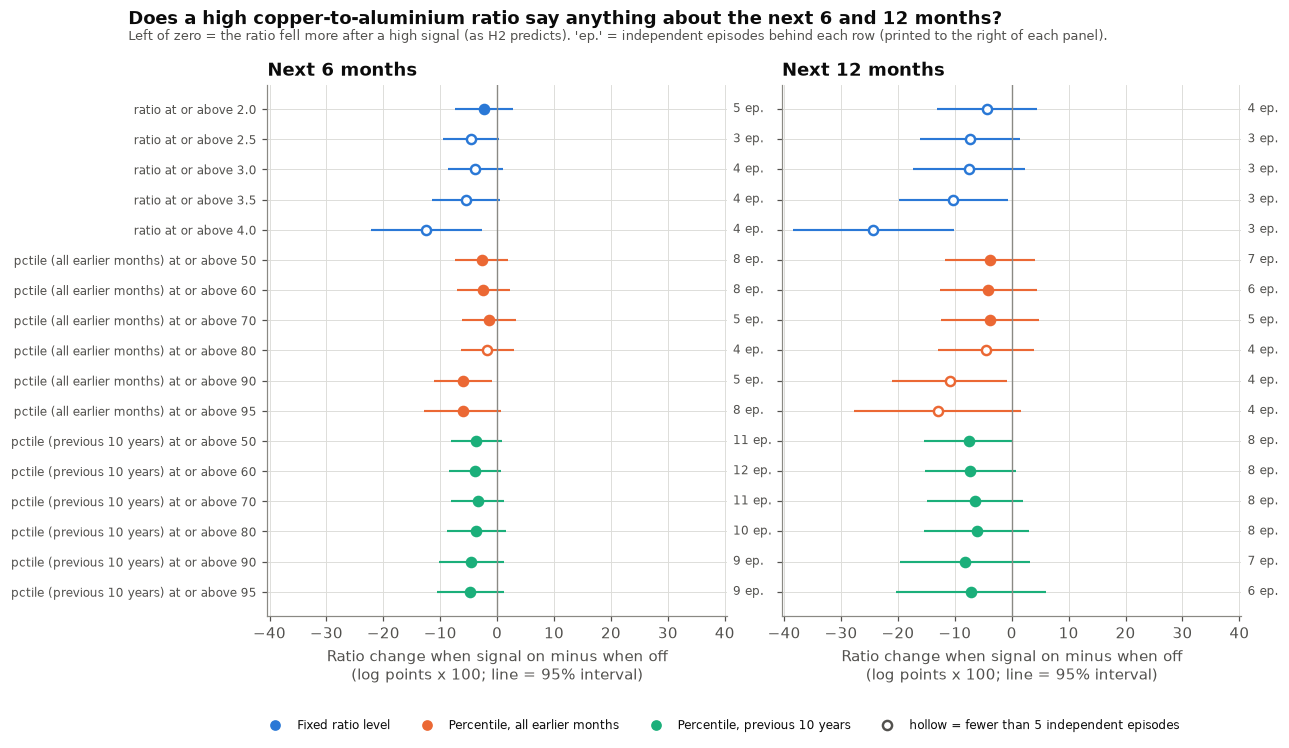

In [8]:
colors = {"fixed_ratio": BLUE, "pctile_all_past": ORANGE, "pctile_past_10y": AQUA}
names = {"fixed_ratio": "Fixed ratio level", "pctile_all_past": "Percentile, all earlier months", "pctile_past_10y": "Percentile, previous 10 years"}
fig, axes = plt.subplots(1, 2, figsize=(11, 6.8), sharey=True, sharex=True)
xmax = np.nanmax(np.abs(thr[["diff_ci_low", "diff_ci_high"]].to_numpy())) * 1.05
for ax, h in zip(axes, [6, 12]):
    t = thr[thr["horizon_m"] == h].reset_index(drop=True)
    y = np.arange(len(t))[::-1]
    for i, row in t.iterrows():
        c = colors[row["rule_type"]]
        thin = row["episodes"] < 5  # fewer than 5 independent episodes: hollow marker
        ax.errorbar(row["diff_logpts"], y[i], xerr=[[row["diff_logpts"] - row["diff_ci_low"]], [row["diff_ci_high"] - row["diff_logpts"]]],
                    fmt="o", color=c, ecolor=c, elinewidth=1.4, ms=6, mfc="white" if thin else c, mew=1.6, capsize=0)
    ax.axvline(0, color="#8a8984", lw=0.9)
    for yi, ep in zip(y, t["episodes"]):
        ax.annotate(f"{ep} ep.", (xmax, yi), xytext=(4, 0), textcoords="offset points", fontsize=8, va="center", color="#52514e", annotation_clip=False)
    ax.set_xlim(-xmax, xmax)
    ax.set_title(f"Next {h} months")
    ax.set_xlabel("Ratio change when signal on minus when off\n(log points x 100; line = 95% interval)")
axes[0].set_yticks(y)
axes[0].set_yticklabels(thr[thr["horizon_m"] == 6]["rule"].str.replace("percentile", "pctile"), fontsize=8)
from matplotlib.lines import Line2D
handles = [Line2D([], [], marker="o", color=c, lw=0, label=names[k]) for k, c in colors.items()]
handles.append(Line2D([], [], marker="o", color="#52514e", mfc="white", mew=1.6, lw=0, label="hollow = fewer than 5 independent episodes"))
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=8, bbox_to_anchor=(0.5, 0.0))
fig.suptitle("Does a high copper-to-aluminium ratio say anything about the next 6 and 12 months?", x=0.01, ha="left", fontweight="bold", fontsize=12)
fig.text(0.01, 0.94, "Left of zero = the ratio fell more after a high signal (as H2 predicts). 'ep.' = independent episodes behind each row (printed to the right of each panel).", fontsize=8.5, color="#52514e")
fig.subplots_adjust(top=0.88, bottom=0.17, right=0.93, wspace=0.12)
plt.show()

## 4. The independent episodes behind the numbers

Each row is one episode: the first month a rule fired, the last month it was still on, and what the ratio, copper and aluminium did over the following 12 months from that first month. For the percentile-of-10-years and fixed rules this is the entire evidence.

In [9]:
ep_rows = []
for (rid, h), g in sig[sig["signal_on"] == 1].groupby(["rule_id", "horizon_m"]):
    for eid, e in g.groupby("episode_id"):
        st = e[e["is_episode_start"] == 1].iloc[0]
        ep_rows.append({"rule_id": rid, "horizon_m": h, "episode_id": int(eid), "first_month": e["month"].min().strftime("%Y-%m"),
                        "last_month_on": e["month"].max().strftime("%Y-%m"), "months_on": len(e),
                        "ratio_change_pct": (np.exp(st["fwd_ratio_logchg"]) - 1) * 100,
                        "copper_change_pct": (np.exp(st["fwd_copper_logret"]) - 1) * 100,
                        "aluminium_change_pct": (np.exp(st["fwd_aluminium_logret"]) - 1) * 100})
episodes = pd.DataFrame(ep_rows).merge(rules[["rule_id", "rule_type", "threshold", "label"]], on="rule_id")
pick = episodes[(episodes["horizon_m"] == 12) & (((episodes["rule_type"] == "fixed_ratio") & episodes["threshold"].isin([3.0, 4.0]))
                                                 | ((episodes["rule_type"] != "fixed_ratio") & (episodes["threshold"] == 90)))]
pick = pick.sort_values(["rule_id", "episode_id"])
pick[["label", "first_month", "last_month_on", "months_on", "ratio_change_pct", "copper_change_pct", "aluminium_change_pct"]].set_index("label").round(1)

,first_month,last_month_on,months_on,ratio_change_pct,copper_change_pct,aluminium_change_pct
label,,,,,,
ratio at or above 3.0,1973-07,1974-06,12,-20.8,-5.0,19.8
ratio at or above 3.0,2006-07,2007-10,5,-4.9,3.4,8.7
ratio at or above 3.0,2009-04,2025-08,186,7.8,75.7,63.1
ratio at or above 4.0,1974-04,1974-04,1,-63.3,-56.2,19.3
ratio at or above 4.0,2012-04,2014-02,10,-3.9,-12.7,-9.2
ratio at or above 4.0,2021-02,2021-05,4,-24.8,17.4,56.1
ratio at or above its 90th percentile of all earlier months,1970-02,1970-04,3,-39.5,-38.4,1.8
ratio at or above its 90th percentile of all earlier months,1973-04,1974-06,14,45.0,90.9,31.7
ratio at or above its 90th percentile of all earlier months,2006-04,2015-10,98,13.2,21.6,7.4


## 5. A threshold-free check: slope of the outcome on the ratio level or percentile

Instead of a cut-off, regress the 6- and 12-month change of the ratio on the ratio's level (in logs) or its percentile, over all months, with HAC standard errors.
A negative slope means: the higher the ratio, the more it fell afterwards. The ratio level is very persistent and the windows overlap, so the effective sample is small and these slopes can look stronger than they are; treat them as description.
The split at January 2000 was chosen before looking, as a round point before the ratio's level shift.

In [10]:
r = ratio.copy()
r["log_ratio"] = np.log(r["cu_al_ratio"])
r["pctile_all"] = r["cu_al_ratio_pctile_all_past"] / 100
r["pctile_10y"] = r["cu_al_ratio_pctile_past_10y"] / 100
preds = {"log of the ratio": "log_ratio", "percentile, all earlier months (0 to 1)": "pctile_all", "percentile, previous 10 years (0 to 1)": "pctile_10y"}
rows = []
for h in (6, 12):
    ycol = f"ratio_fwd_{h}m_logchg"
    base = r.dropna(subset=["pctile_all", ycol])
    for period, d in [("1970-01 to latest", base), ("1970-01 to 1999-12", base.loc[:"1999-12-01"]), ("2000-01 to latest", base.loc["2000-01-01":])]:
        for pname, pcol in preds.items():
            m = sm.OLS(d[ycol].to_numpy(), sm.add_constant(d[pcol].to_numpy())).fit(cov_type="HAC", cov_kwds={"maxlags": h})
            ci = m.conf_int()[1]
            rows.append({"horizon_m": h, "period": period, "predictor": pname, "slope": m.params[1], "slope_ci_low": ci[0], "slope_ci_high": ci[1],
                         "p_hac": m.pvalues[1], "r_squared": m.rsquared, "months": int(m.nobs)})
cont = pd.DataFrame(rows)
show(cont.set_index(["horizon_m", "period", "predictor"]), 3)

slope  \
horizon_m period             predictor                                        
6         1970-01 to latest  log of the ratio                        -0.056   
                             percentile, all earlier months (0 to 1) -0.065   
                             percentile, previous 10 years (0 to 1)  -0.068   
          1970-01 to 1999-12 log of the ratio                        -0.280   
                             percentile, all earlier months (0 to 1) -0.236   
                             percentile, previous 10 years (0 to 1)  -0.151   
          2000-01 to latest  log of the ratio                        -0.077   
                             percentile, all earlier months (0 to 1) -0.067   
                             percentile, previous 10 years (0 to 1)  -0.024   
12        1970-01 to latest  log of the ratio                        -0.092   
                             percentile, all earlier months (0 to 1) -0.113   
                             percentile, previous 10 years (0 to 1)  -0.111   
          1970-01 to 1999-12 log of the ratio                        -0.479   
                             percentile, all earlier months (0 to 1) -0.421   
                             percentile, previous 10 years (0 to 1)  -0.255   
          2000-01 to latest  log of the ratio                        -0.124   
                             percentile, all earlier months (0 to 1) -0.111   
                             percentile, previous 10 years (0 to 1)  -0.033   

                                                                      slope_ci_low  \
horizon_m period             predictor                                               
6         1970-01 to latest  log of the ratio                               -0.109   
                             percentile, all earlier months (0 to 1)        -0.139   
                             percentile, previous 10 years (0 to 1)         -0.143   
          1970-01 to 1999-12 log of the ratio                               -0.514   
                             percentile, all earlier months (0 to 1)        -0.444   
                             percentile, previous 10 years (0 to 1)         -0.289   
          2000-01 to latest  log of the ratio                               -0.139   
                             percentile, all earlier months (0 to 1)        -0.153   
                             percentile, previous 10 years (0 to 1)         -0.089   
12        1970-01 to latest  log of the ratio                               -0.184   
                             percentile, all earlier months (0 to 1)        -0.239   
                             percentile, previous 10 years (0 to 1)         -0.240   
          1970-01 to 1999-12 log of the ratio                               -0.783   
                             percentile, all earlier months (0 to 1)        -0.726   
                             percentile, previous 10 years (0 to 1)         -0.476   
          2000-01 to latest  log of the ratio                               -0.236   
                             percentile, all earlier months (0 to 1)        -0.275   
                             percentile, previous 10 years (0 to 1)         -0.144   

                                                                      slope_ci_high  \
horizon_m period             predictor                                                
6         1970-01 to latest  log of the ratio                                -0.003   
                             percentile, all earlier months (0 to 1)          0.010   
                             percentile, previous 10 years (0 to 1)           0.007   
          1970-01 to 1999-12 log of the ratio                                -0.046   
                             percentile, all earlier months (0 to 1)         -0.028   
                             percentile, previous 10 years (0 to 1)          -0.013   
          2000-01 to latest  log of the ratio                           

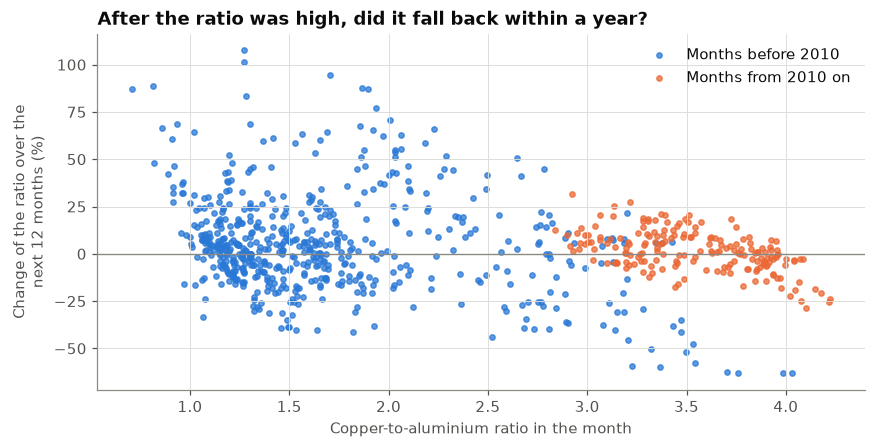

In [11]:
fig, ax = plt.subplots()
d = r.dropna(subset=["ratio_fwd_12m_pct"])
early, late = d.loc[:"2009-12-01"], d.loc["2010-01-01":]
ax.scatter(early["cu_al_ratio"], early["ratio_fwd_12m_pct"], s=12, color=BLUE, alpha=0.75, label="Months before 2010")
ax.scatter(late["cu_al_ratio"], late["ratio_fwd_12m_pct"], s=12, color=ORANGE, alpha=0.75, label="Months from 2010 on")
ax.axhline(0, color="#8a8984", lw=0.9)
ax.set_xlabel("Copper-to-aluminium ratio in the month")
ax.set_ylabel("Change of the ratio over the\nnext 12 months (%)")
ax.set_title("After the ratio was high, did it fall back within a year?")
ax.legend(loc="upper right")
plt.show()

Each dot is one month; neighbouring months are almost the same dot, so the cloud has far fewer independent points than it seems.

## 6. Summary of results
The numbers below are printed from the tables above, so they always match the code.

In [12]:
def pr(label, d):
    print(label)
    for _, x in d.iterrows():
        print(f"  {x['rule']}: on-minus-off {x['diff_logpts']:.1f} [{x['diff_ci_low']:.1f}, {x['diff_ci_high']:.1f}] log pts, "
              f"p {x['p_hac']:.3f}, Holm p {x['p_holm']:.3f}, {int(x['months_on'])} months, {int(x['episodes'])} episodes, {int(x['episodes_falling'])} falling")


for h in (12, 6):
    for typ in colors:
        pr(f"{h}-month outcome, {names[typ]}:", thr[(thr["horizon_m"] == h) & (thr["rule_type"] == typ)])
print("Rules with a negative on-minus-off difference:", int((thr["diff_logpts"] < 0).sum()), "of", int(thr["diff_logpts"].notna().sum()))
print("Rules with Holm p below 0.05:", int((thr["p_holm"] < 0.05).sum()), "of", int(thr["p_holm"].notna().sum()), "tested")
print("Rules with raw HAC p below 0.05:", int((thr["p_hac"] < 0.05).sum()))
print("Slopes (all months, 1970 on):")
for _, x in cont[cont["period"] == "1970-01 to latest"].iterrows():
    print(f"  {x['horizon_m']}m, {x['predictor']}: {x['slope']:.3f} [{x['slope_ci_low']:.3f}, {x['slope_ci_high']:.3f}], R2 {x['r_squared']:.3f}")
print("Slopes by period, 12m, log ratio:")
for _, x in cont[(cont["horizon_m"] == 12) & (cont["predictor"] == "log of the ratio")].iterrows():
    print(f"  {x['period']}: {x['slope']:.3f} [{x['slope_ci_low']:.3f}, {x['slope_ci_high']:.3f}], n {x['months']}")

12-month outcome, Fixed ratio level:
  ratio at or above 2.0: on-minus-off -4.3 [-13.1, 4.5] log pts, p 0.339, Holm p 1.000, 275 months, 4 episodes, 2 falling
  ratio at or above 2.5: on-minus-off -7.4 [-16.2, 1.4] log pts, p 0.100, Holm p 1.000, 245 months, 3 episodes, 2 falling
  ratio at or above 3.0: on-minus-off -7.5 [-17.4, 2.3] log pts, p 0.133, Holm p 1.000, 203 months, 3 episodes, 2 falling
  ratio at or above 3.5: on-minus-off -10.3 [-19.8, -0.7] log pts, p 0.035, Holm p 1.000, 100 months, 3 episodes, 1 falling
  ratio at or above 4.0: on-minus-off -24.3 [-38.4, -10.1] log pts, p 0.001, Holm p 0.026, 15 months, 3 episodes, 3 falling
12-month outcome, Percentile, all earlier months:
  percentile (all earlier months) at or above 50: on-minus-off -3.9 [-11.7, 4.0] log pts, p 0.337, Holm p 1.000, 395 months, 7 episodes, 4 falling
  percentile (all earlier months) at or above 60: on-minus-off -4.1 [-12.7, 4.4] log pts, p 0.345, Holm p 1.000, 345 months, 6 episodes, 3 falling
  per

## 7. What this does and does not show
*(written after reading the results above)*

**What the data show in this sample (World Bank monthly prices, rules tested from 1970 to the latest outcome)**

- **The direction matches H2, but the evidence is weak.** In all 34 comparisons (17 rules, 2 horizons) the ratio fell more after a "high ratio" signal than otherwise. Only 5 of the 34 intervals exclude zero, and only 1 survives the Holm adjustment for testing many rules (the fixed ratio of 4.0 at 12 months). Most intervals run from clearly negative to slightly positive.
- **The size grows with the threshold.** Over the next 12 months the ratio changed on average by +1.0% across all months (+0.3% over 6 months). When it was at or above 3.0 it fell 4.2% on average (against a rise of 3.3% otherwise); at or above 3.5, it fell 7.5% (against +2.6%); at or above 4.0, it fell 20.3% (against +1.6%). The percentile rules are similar in direction and smaller in size (for example -6.9% for the 90th percentile of all earlier months).
- **The number of independent episodes is small.** The rules rest on 3 to 12 independent episodes, not on the hundreds of signal months. The fixed ratio of 4.0 has 15 signal months in 3 episodes (April 1974, April 2012, February 2021). The ratio fell 12 months after the start of each (3 of 3; the 95% interval for that share is 44% to 100%). The fall came from different sources each time: copper dropped about 56% in 1974 and 13% in 2012, while in 2021 copper rose 17% and aluminium rose 56%. With 3 episodes the HAC p-value (0.001) should not be taken at face value, because HAC assumes many independent clusters; the hollow markers in the chart flag every rule with fewer than 5 episodes.
- **Episodes are very uneven.** For the fixed ratio of 3.0, one "episode" lasts from April 2009 to August 2025 (186 months). Twelve months after it started the ratio was 7.8% *higher* (copper +76%, aluminium +63%). Merging overlapping windows removes double counting, but it leaves very few independent observations and the first month of an episode is a thin summary of a long one.
- **Today is outside the historical experience.** The August 2026 ratio is 4.41 (copper 14,326, aluminium 3,251 USD per tonne), the highest in the 800-month history, at the 100th percentile of both its whole past and the previous 10 years. The 4.0 rule had only 15 months to learn from, and nothing here tells us what happens at 4.4.
- **The threshold-free check says little.** The slope of the 12-month change on the log of the ratio is -0.09 (interval -0.18 to -0.001) and explains about 4% of the variation (R squared 0.04); the 6-month slope is -0.06 (R squared 0.025). The percentile versions have intervals that include zero. The slope was much steeper before 2000 (-0.48, interval -0.78 to -0.18, 360 months) than since (-0.12, interval -0.24 to -0.01, 308 months), so mean reversion looks weaker in the period that matters most today.
- **Scenario arithmetic, not a forecast.** To get from 4.41 back to the median since 2010 (3.54), copper would have to fall about 20% with aluminium unchanged, or aluminium rise about 24% with copper unchanged. Back to the median since 1970 (1.71) it would take a 61% fall in copper or a 158% rise in aluminium.

**What this does not show**

- **Substitution.** There is no demand data in this project, so nothing here says whether anyone switches between the metals. A falling ratio is a price movement, not evidence of substitution.
- **A usable trading or forecasting signal.** The ratio has a level shift (median about 1.3 to 1.9 for decades, 2.8 to 4.4 since 2010), most high-ratio months fall in one post-2009 period, and the slopes explain very little. Different rules and horizons give different answers, so the table by threshold is meant for reading the pattern, not for picking the best row.
- **Anything about causes.** Why the ratio fell after each high episode (copper demand, aluminium supply, currencies, energy) is not examined. Both prices are in US dollars, so dollar effects partly cancel in the ratio, but this was not tested.
- **Real prices.** The ratio is computed from nominal monthly averages; for a ratio of two prices in the same currency, inflation largely cancels, but this was not checked.

## 8. Save the derived results
For the dashboard: the threshold table, the slopes, the list of episodes and today's context. CSV files go to `results/`, and a database rebuild reloads them as `res_` tables.

In [13]:
import os

os.makedirs("../results", exist_ok=True)


def save(df, name):
    out = df.reset_index() if df.index.name or isinstance(df.index, pd.MultiIndex) else df
    out.to_csv(f"../results/{name}.csv", index=False)
    out.to_sql(name, con, if_exists="replace", index=False)


save(thr[["rule_id", "rule_type", "threshold", "label", "horizon_m", "months_on", "months_off", "share_on_pct", "episodes",
          "avg_ratio_change_all_pct", "avg_ratio_change_on_pct", "avg_ratio_change_off_pct", "falling_share_on_pct", "falling_share_off_pct",
          "avg_copper_change_on_pct", "avg_aluminium_change_on_pct", "diff_logpts", "diff_ci_low", "diff_ci_high", "p_hac", "p_holm",
          "episode_avg_change_pct", "episodes_falling", "episodes_falling_ci_low_pct", "episodes_falling_ci_high_pct"]], "res_cu_al_threshold_table")
save(cont, "res_cu_al_slopes")
save(episodes.sort_values(["rule_id", "horizon_m", "episode_id"]), "res_cu_al_episodes")
save(ctx.rename(columns={"reference ratio": "reference_ratio", "today's ratio": "todays_ratio",
                         "copper would have to fall by (%), aluminium unchanged": "copper_change_needed_pct",
                         "aluminium would have to rise by (%), copper unchanged": "aluminium_change_needed_pct"}).rename_axis("reference"),
     "res_cu_al_scenario_today")
con.commit()
con.close()
print("Saved 4 result tables")

Saved 4 result tables
